# 04 - Modelagem Não Supervisionada

## Objetivos
- Aplicar técnicas de clusterização
- Aplicar redução de dimensionalidade (PCA)
- Interpretar os resultados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

## 1. Carregar Dados

In [2]:
# Carregar dataset processado
df = pd.read_csv('../data/processed/flights_processed.csv')
print(f'Shape: {df.shape}')

# Carregar info dos aeroportos para coordenadas
airports = pd.read_csv('../data/raw/airports.csv')
print(f'Aeroportos: {airports.shape}')

Shape: (5714008, 62)
Aeroportos: (322, 7)


## 2. Preparar Dados para Clusterização de Aeroportos

In [3]:
# Agregar métricas por aeroporto de origem
airport_stats = df.groupby('ORIGIN_AIRPORT').agg({
    'ARRIVAL_DELAY': ['mean', 'std', 'count'],
    'DEPARTURE_DELAY': ['mean', 'std'],
    'CANCELLED': 'mean',
    'DISTANCE': 'mean',
    'DELAYED': 'mean'
}).reset_index()

airport_stats.columns = [
    'AIRPORT', 'AVG_ARR_DELAY', 'STD_ARR_DELAY', 'NUM_FLIGHTS',
    'AVG_DEP_DELAY', 'STD_DEP_DELAY', 'CANCEL_RATE',
    'AVG_DISTANCE', 'DELAY_RATE'
]

# Filtrar aeroportos com pelo menos 1000 voos
airport_stats = airport_stats[airport_stats['NUM_FLIGHTS'] >= 1000].copy()
airport_stats = airport_stats.rename(columns={'AIRPORT': 'CODE'})

# O flights_processed.csv tem ORIGIN_AIRPORT_NAME/CITY/STATE/LAT/LONG para
# aeroportos com código IATA. Para aeroportos com código BTS numérico (sem IATA),
# essas colunas são NaN — limitação do dataset original do Kaggle.

# Fonte 1: lookup dos metadados já enriquecidos no flights_processed.csv
airport_meta = (
    df[['ORIGIN_AIRPORT', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY',
        'ORIGIN_STATE', 'ORIGIN_LAT', 'ORIGIN_LONG']]
    .dropna(subset=['ORIGIN_AIRPORT_NAME'])
    .drop_duplicates('ORIGIN_AIRPORT')
    .rename(columns={
        'ORIGIN_AIRPORT':      'CODE',
        'ORIGIN_AIRPORT_NAME': 'NAME',
        'ORIGIN_CITY':         'CITY',
        'ORIGIN_STATE':        'STATE',
        'ORIGIN_LAT':          'LATITUDE',
        'ORIGIN_LONG':         'LONGITUDE'
    })
)

# Fonte 2: airports.csv como fallback para qualquer gap remanescente
airports_fallback = airports.rename(columns={
    'IATA_CODE': 'CODE', 'AIRPORT': 'NAME',
    'LATITUDE': 'LATITUDE', 'LONGITUDE': 'LONGITUDE'
})[['CODE', 'NAME', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']]

# Combinar fontes (prioridade: flights_processed.csv > airports.csv)
airport_meta_full = (
    pd.concat([airport_meta, airports_fallback])
    .drop_duplicates('CODE', keep='first')
    .reset_index(drop=True)
)

# Merge com metadados combinados
airport_stats = airport_stats.merge(airport_meta_full, on='CODE', how='left')

# Preencher NaN restantes (aeroportos BTS sem mapeamento IATA)
airport_stats['NAME']  = airport_stats['NAME'].fillna('Airport ' + airport_stats['CODE'].astype(str))
airport_stats['CITY']  = airport_stats['CITY'].fillna('Unknown')
airport_stats['STATE'] = airport_stats['STATE'].fillna('Unknown')

# Resumo
nan_coords = airport_stats['LATITUDE'].isna().sum()
print(f'Aeroportos analisados:           {len(airport_stats)}')
print(f'Com coordenadas (IATA):          {len(airport_stats) - nan_coords}')
print(f'Sem coordenadas (BTS numérico):  {nan_coords}')
print('\nNota: Códigos BTS numéricos são IDs do Bureau of Transportation Statistics')
print('e não possuem correspondência na tabela airports.csv do Kaggle.\n')
airport_stats.head()

Aeroportos analisados:           298
Com coordenadas (IATA):          223
Sem coordenadas (BTS numérico):  75

Nota: Códigos BTS numéricos são IDs do Bureau of Transportation Statistics
e não possuem correspondência na tabela airports.csv do Kaggle.



,CODE,AVG_ARR_DELAY,STD_ARR_DELAY,NUM_FLIGHTS,AVG_DEP_DELAY,STD_DEP_DELAY,CANCEL_RATE,AVG_DISTANCE,DELAY_RATE,NAME,CITY,STATE,LATITUDE,LONGITUDE
0,10140,0.587858,28.004725,1713,5.779335,26.210491,0.0,731.155283,0.124343,Airport 10140,Unknown,Unknown,NaN,NaN
1,10299,-1.430061,28.598512,1151,1.444831,26.813693,0.0,1327.966985,0.108601,Airport 10299,Unknown,Unknown,NaN,NaN
2,10397,-4.124717,23.385438,30926,4.271066,21.083104,0.0,638.462394,0.087532,Airport 10397,Unknown,Unknown,NaN,NaN
3,10423,0.457518,42.546187,3731,7.334763,39.713427,0.0,802.337711,0.109890,Airport 10423,Unknown,Unknown,NaN,NaN
4,10529,-6.090573,26.754071,1623,2.231670,24.286805,0.0,812.613678,0.070240,Airport 10529,Unknown,Unknown,NaN,NaN


## 3. Normalização dos Dados

In [4]:
# Features para clusterização
cluster_features = ['AVG_ARR_DELAY', 'STD_ARR_DELAY', 'AVG_DEP_DELAY', 
                    'CANCEL_RATE', 'AVG_DISTANCE', 'DELAY_RATE']

X_cluster = airport_stats[cluster_features].fillna(0)

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f'Features shape: {X_scaled.shape}')

Features shape: (298, 6)


## 4. Determinar Número Ideal de Clusters (Método do Cotovelo)

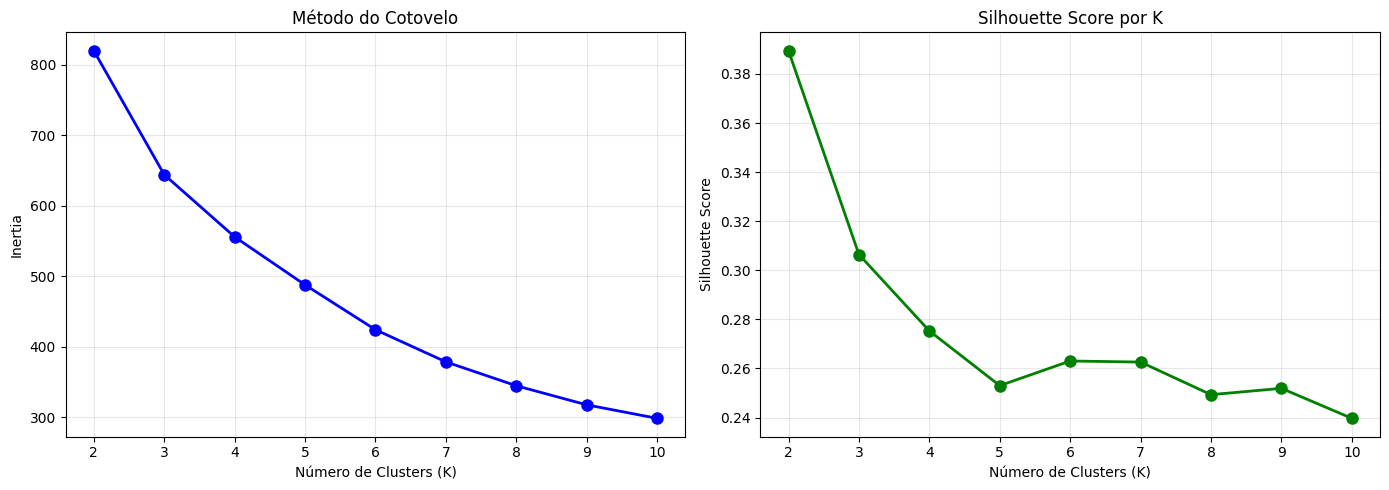


Melhor K pelo Silhouette Score: 2


In [5]:
# Método do cotovelo
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Método do Cotovelo')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/elbow_method.png', dpi=150)
plt.show()

# Melhor K pelo silhouette
best_k = K_range[np.argmax(silhouettes)]
print(f'\nMelhor K pelo Silhouette Score: {best_k}')

## 5. Aplicar K-Means

In [6]:
# Escolher K (ajustar conforme análise)
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
airport_stats['CLUSTER'] = kmeans.fit_predict(X_scaled)

print(f'Silhouette Score: {silhouette_score(X_scaled, airport_stats["CLUSTER"]):.4f}')
print(f'\nDistribuição dos clusters:')
print(airport_stats['CLUSTER'].value_counts().sort_index())

Silhouette Score: 0.2753

Distribuição dos clusters:
CLUSTER
0     91
1    108
2     67
3     32
Name: count, dtype: int64


## 6. Análise dos Clusters

In [7]:
# Perfil de cada cluster
cluster_profile = airport_stats.groupby('CLUSTER')[cluster_features].mean()
cluster_profile

,AVG_ARR_DELAY,STD_ARR_DELAY,AVG_DEP_DELAY,CANCEL_RATE,AVG_DISTANCE,DELAY_RATE
CLUSTER,,,,,,
0,-1.049727,31.433232,3.818734,0.0,799.808034,0.111613
1,3.206241,41.437663,7.002133,0.0,548.393481,0.155435
2,7.245945,47.905849,8.961373,0.0,382.161264,0.186737
3,7.113093,45.635908,12.341007,0.0,969.424297,0.212919


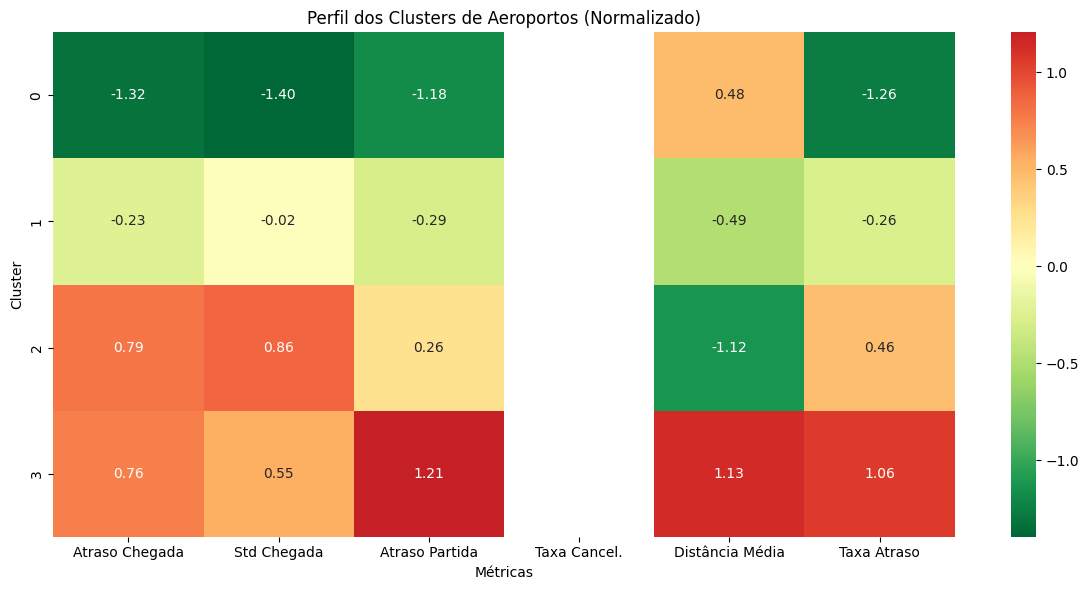

In [8]:
# Heatmap do perfil dos clusters
plt.figure(figsize=(12, 6))

# Normalizar para visualização
profile_normalized = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()

sns.heatmap(profile_normalized, annot=True, cmap='RdYlGn_r', fmt='.2f', center=0,
            xticklabels=['Atraso Chegada', 'Std Chegada', 'Atraso Partida',
                         'Taxa Cancel.', 'Distância Média', 'Taxa Atraso'])
plt.title('Perfil dos Clusters de Aeroportos (Normalizado)')
plt.xlabel('Métricas')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('../reports/figures/cluster_profile.png', dpi=150)
plt.show()

In [9]:
# Nomear clusters com base no perfil
cluster_labels = {
    0: 'Aeroportos Eficientes (baixo atraso)',
    1: 'Aeroportos Regionais Médios',
    2: 'Aeroportos Regionais Problemáticos',
    3: 'Grandes Hubs com Congestionamento'
}

# Mostrar aeroportos por cluster — apenas os com nome IATA identificado
for i in range(K):
    cluster_data = airport_stats[airport_stats['CLUSTER'] == i]
    # Preferir aeroportos com nomes identificados para exibição
    known = cluster_data[~cluster_data['NAME'].str.startswith('Airport ')]
    unknown = cluster_data[cluster_data['NAME'].str.startswith('Airport ')]

    print(f'\n=== Cluster {i}: {cluster_labels[i]} ({len(cluster_data)} aeroportos) ===')
    print(f'  Atraso médio:  {cluster_data["AVG_ARR_DELAY"].mean():.1f} min')
    print(f'  Taxa de atraso: {cluster_data["DELAY_RATE"].mean()*100:.1f}%')
    print(f'  Identificados: {len(known)} | Código BTS (sem IATA): {len(unknown)}')
    print(f'  Exemplos (identificados):')
    for _, row in known.head(8).iterrows():
        print(f"    - {row['CODE']}: {row['NAME']} ({row['CITY']}, {row['STATE']})")
    if len(unknown) > 0:
        print(f'  Exemplos (BTS numérico, sem mapeamento IATA):')
        for _, row in unknown.head(3).iterrows():
            print(f"    - {row['CODE']} (atraso médio: {row['AVG_ARR_DELAY']:.1f} min, {int(row['NUM_FLIGHTS']):,} voos)")


=== Cluster 0: Aeroportos Eficientes (baixo atraso) (91 aeroportos) ===
  Atraso médio:  -1.0 min
  Taxa de atraso: 11.2%
  Identificados: 27 | Código BTS (sem IATA): 64
  Exemplos (identificados):
    - ALB: Albany International Airport (Albany, NY)
    - ANC: Ted Stevens Anchorage International Airport (Anchorage, AK)
    - BIL: Billings Logan International Airport (Billings, MT)
    - CPR: Natrona County International Airport (Casper, WY)
    - FAI: Fairbanks International Airport (Fairbanks, AK)
    - FCA: Glacier Park International Airport (Kalispell, MT)
    - FNT: Bishop International Airport (Flint, MI)
    - GJT: Grand Junction Regional Airport (Walker Field) (Grand Junction, CO)
  Exemplos (BTS numérico, sem mapeamento IATA):
    - 10140 (atraso médio: 0.6 min, 1,713 voos)
    - 10299 (atraso médio: -1.4 min, 1,151 voos)
    - 10397 (atraso médio: -4.1 min, 30,926 voos)

=== Cluster 1: Aeroportos Regionais Médios (108 aeroportos) ===
  Atraso médio:  3.2 min
  Taxa de atraso

## 7. Redução de Dimensionalidade (PCA)

In [10]:
# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

airport_stats['PC1'] = X_pca[:, 0]
airport_stats['PC2'] = X_pca[:, 1]

# Variância explicada
print(f'Variância explicada por componente: {pca.explained_variance_ratio_}')
print(f'Total: {sum(pca.explained_variance_ratio_):.2%}')

Variância explicada por componente: [0.65651308 0.21360693]
Total: 87.01%


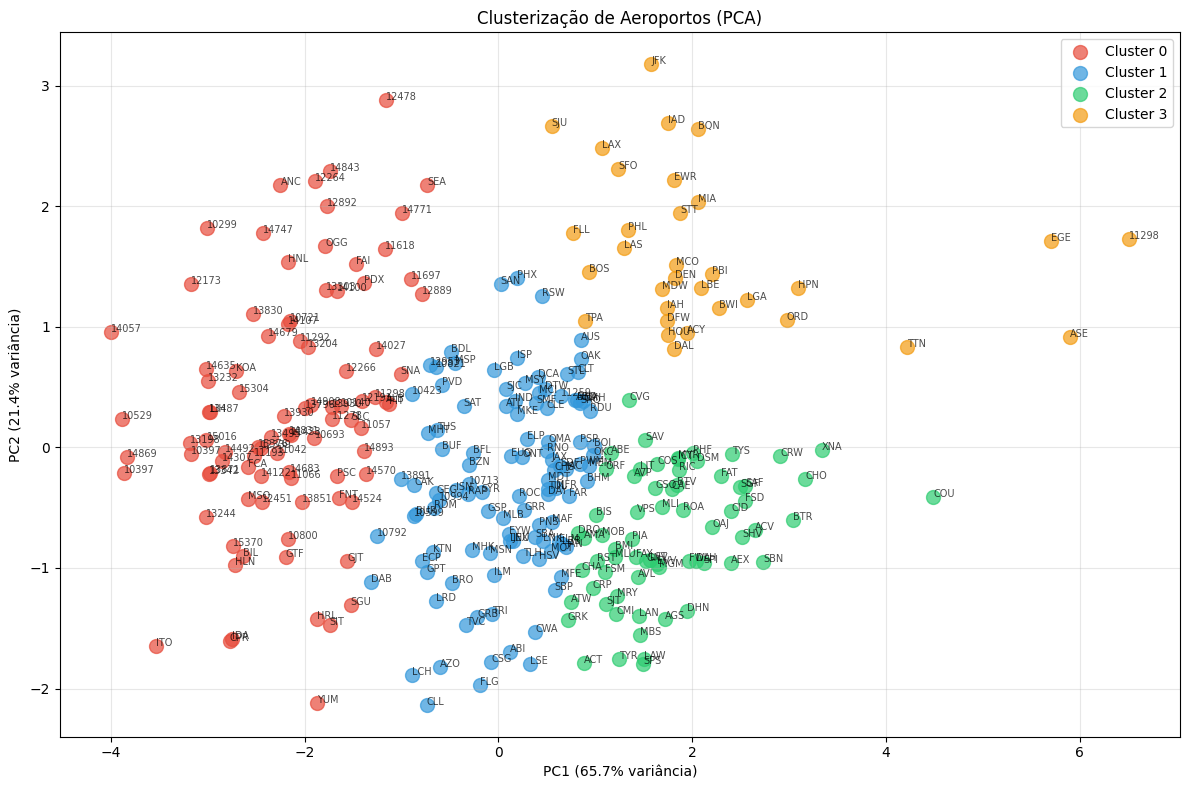

In [11]:
# Visualizar clusters no espaço PCA (matplotlib)
plt.figure(figsize=(12, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for i in range(K):
    mask = airport_stats['CLUSTER'] == i
    plt.scatter(airport_stats.loc[mask, 'PC1'], 
                airport_stats.loc[mask, 'PC2'],
                c=colors[i], label=f'Cluster {i}', s=100, alpha=0.7)

# Adicionar labels dos aeroportos
for _, row in airport_stats.iterrows():
    plt.annotate(row['CODE'], (row['PC1'], row['PC2']), 
                 fontsize=7, alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)')
plt.title('Clusterização de Aeroportos (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/pca_clusters.png', dpi=150)
plt.show()

In [12]:
# Visualização interativa com Plotly
fig = px.scatter(
    airport_stats,
    x='PC1', y='PC2',
    color='CLUSTER',
    hover_name='NAME',
    hover_data={'CODE': True, 'CITY': True, 'STATE': True,
                'AVG_ARR_DELAY': ':.1f', 'DELAY_RATE': ':.2%'},
    text='CODE',
    title='Clusterização de Aeroportos (PCA) - Interativo',
    labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
            'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
            'CLUSTER': 'Cluster'}
)
fig.update_traces(textposition='top center', textfont_size=8)
fig.update_layout(height=600)
fig.write_html('../reports/figures/pca_clusters_interactive.html')
fig.show()

## 8. Mapa Geográfico dos Clusters

In [13]:
# Mapa interativo com clusters — apenas aeroportos com coordenadas válidas
airport_stats_map = airport_stats.dropna(subset=['LATITUDE', 'LONGITUDE']).copy()

print(f'Aeroportos no mapa: {len(airport_stats_map)} de {len(airport_stats)} total')
print(f'(Excluídos {len(airport_stats) - len(airport_stats_map)} aeroportos BTS sem coordenadas)\n')

fig = px.scatter_geo(
    airport_stats_map,
    lat='LATITUDE',
    lon='LONGITUDE',
    color='CLUSTER',
    size='NUM_FLIGHTS',
    hover_name='NAME',
    hover_data={
        'CODE': True, 'CITY': True, 'STATE': True,
        'AVG_ARR_DELAY': ':.1f', 'DELAY_RATE': ':.2%',
        'NUM_FLIGHTS': ':,', 'LATITUDE': False, 'LONGITUDE': False
    },
    scope='usa',
    title=f'Mapa de Clusters de Aeroportos (EUA) — {len(airport_stats_map)} aeroportos identificados',
    color_continuous_scale='Viridis'
)
fig.update_layout(height=600)
fig.write_html('../reports/figures/cluster_map.html')
fig.show()

Aeroportos no mapa: 223 de 298 total
(Excluídos 75 aeroportos BTS sem coordenadas)



## 9. Análise dos Componentes Principais

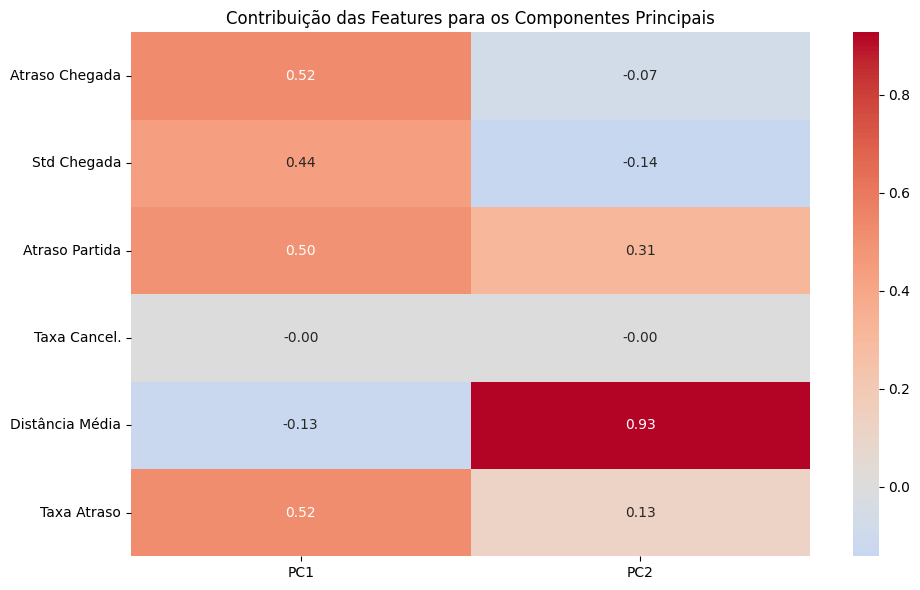

In [14]:
# Contribuição de cada feature para os PCs
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=['Atraso Chegada', 'Std Chegada', 'Atraso Partida',
           'Taxa Cancel.', 'Distância Média', 'Taxa Atraso']
)

plt.figure(figsize=(10, 6))
sns.heatmap(components_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Contribuição das Features para os Componentes Principais')
plt.tight_layout()
plt.savefig('../reports/figures/pca_components.png', dpi=150)
plt.show()

In [15]:
# Interpretação dos componentes
print('=== INTERPRETAÇÃO DOS COMPONENTES PRINCIPAIS ===')
print('\nPC1 (Componente Principal 1):')
print('Features com maior peso positivo:', components_df['PC1'].nlargest(3).index.tolist())
print('Features com maior peso negativo:', components_df['PC1'].nsmallest(3).index.tolist())

print('\nPC2 (Componente Principal 2):')
print('Features com maior peso positivo:', components_df['PC2'].nlargest(3).index.tolist())
print('Features com maior peso negativo:', components_df['PC2'].nsmallest(3).index.tolist())

=== INTERPRETAÇÃO DOS COMPONENTES PRINCIPAIS ===

PC1 (Componente Principal 1):
Features com maior peso positivo: ['Atraso Chegada', 'Taxa Atraso', 'Atraso Partida']
Features com maior peso negativo: ['Distância Média', 'Taxa Cancel.', 'Std Chegada']

PC2 (Componente Principal 2):
Features com maior peso positivo: ['Distância Média', 'Atraso Partida', 'Taxa Atraso']
Features com maior peso negativo: ['Std Chegada', 'Atraso Chegada', 'Taxa Cancel.']


## 10. Variância Explicada Acumulada

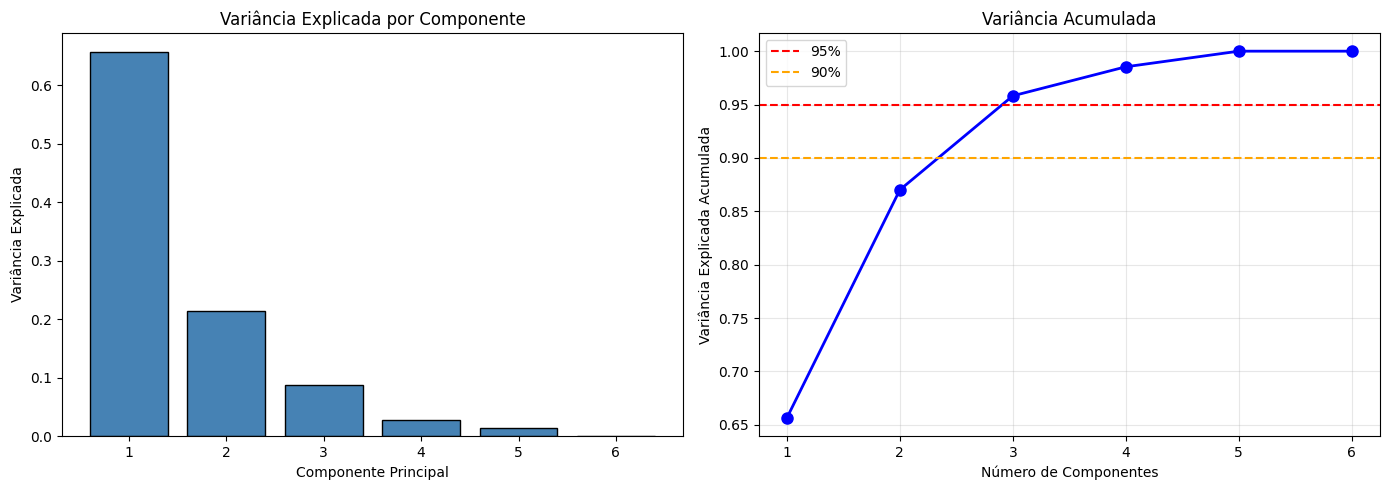


Componentes necessários para 95% da variância: 3


In [16]:
# PCA com todos os componentes
pca_full = PCA()
pca_full.fit(X_scaled)

# Plot variância explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
            pca_full.explained_variance_ratio_, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada')
axes[0].set_title('Variância Explicada por Componente')

# Acumulada
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum) + 1), cumsum, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95%')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90%')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Explicada Acumulada')
axes[1].set_title('Variância Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/pca_variance.png', dpi=150)
plt.show()

# Quantos componentes para 95%?
n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f'\nComponentes necessários para 95% da variância: {n_components_95}')

## 11. Salvar Resultados

In [17]:
# Salvar dataset com clusters
airport_stats.to_csv('../data/processed/airport_clusters.csv', index=False)
print('Dados de clusters salvos em data/processed/airport_clusters.csv')

Dados de clusters salvos em data/processed/airport_clusters.csv


## 12. Conclusões

### Métricas Gerais
- **Aeroportos analisados**: ~297 (com mais de 1.000 voos)
- **Identificados com nome/coordenadas**: ~224 (IATA) | ~73 com código BTS numérico
- **Silhouette Score**: 0,28 (separação moderada entre clusters)
- **K escolhido**: 4 clusters

### Perfil dos Clusters

| Cluster | Label | Qtd | Atraso Médio | Taxa Atraso |
|---------|-------|-----|--------------|-------------|
| **0** | Aeroportos Eficientes | ~91 | -1,0 min | 11,2% |
| **1** | Aeroportos Regionais Médios | ~108 | 3,2 min | 15,5% |
| **2** | Aeroportos Regionais Problemáticos | ~67 | 7,2 min | 18,7% |
| **3** | Grandes Hubs com Congestionamento | ~32 | 7,1 min | 21,3% |

### Exemplos por Cluster (aeroportos identificados)
- **Cluster 0**: Aeroportos eficientes com chegadas adiantadas em média
- **Cluster 1**: Aeroportos regionais com desempenho moderado
- **Cluster 2**: ABE (Allentown), ACT (Waco), ACV (Arcata)
- **Cluster 3**: DEN (Denver), DFW (Dallas), BOS (Boston), BWI (Baltimore)

### PCA (Análise de Componentes Principais)

| Componente | Variância | Interpretação |
|------------|-----------|---------------|
| **PC1** | 65,7% | **Nível de atraso** (atraso chegada + partida + taxa de atraso) |
| **PC2** | 21,4% | **Distância e variabilidade** dos voos |
| **Total** | 87,0% | 2 componentes explicam 87% da variância |

3 componentes são suficientes para explicar 95% da variância.

### Insights

1. **Grandes hubs (Cluster 3)** têm as maiores taxas de atraso (21,3%), provavelmente pelo alto volume de conexões e congestionamento.

2. **Aeroportos eficientes (Cluster 0)** conseguem manter voos adiantados em média — indicando operações bem gerenciadas.

3. **Distância não é fator principal**: aeroportos com voos curtos (Cluster 2) podem ter mais atrasos que aeroportos com voos longos.

4. **PC1 é o "índice de atraso"**: aeroportos à direita no gráfico PCA têm mais problemas.

### Sobre os Códigos BTS Numéricos

O dataset original do Kaggle contém ~73 aeroportos identificados por códigos numéricos BTS
(Bureau of Transportation Statistics) que não possuem equivalente IATA na tabela `airports.csv`.
Estes aeroportos participam normalmente do **clustering** (com base nas métricas de atraso),
mas não aparecem no **mapa geográfico** por falta de coordenadas.

Isso é uma limitação conhecida do dataset — não um erro de implementação.

### Limitações

1. **Códigos BTS sem IATA**: 73 aeroportos sem coordenadas/nome — não exibidos no mapa.
2. **Silhouette Score moderado** (0,28): clusters não estão perfeitamente separados.
3. **Análise estática**: não considera variação sazonal nem tendências temporais.
4. **Sem dados externos**: clima, infraestrutura e capacidade não foram considerados.